## Introduzione:
Nel seguente Notebook analizzeremo i dati ricavati dal sito Terna dell'energia prodotta nel 2025 in Italia divisi per fonte primaria

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns   
import matplotlib.pyplot as plt


In [16]:
dati_consumo = pd.read_excel('Terna_generazione_2025.xlsx')
print('File Caricato')
print(dati_consumo.dtypes)
dati_consumo.head()

c:\Users\roddn\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


File Caricato
Date                  object
Actual Generation    float64
Primary Source           str
dtype: object


,Date,Actual Generation,Primary Source
0,2025-12-31 23:45:00,17.280,Thermal
1,2025-12-31 23:45:00,1.120,Wind
2,2025-12-31 23:45:00,0.600,Geothermal
3,2025-12-31 23:45:00,0.000,Photovoltaic
4,2025-12-31 23:45:00,2.196,Self-consumption


Self-consumption indica l'energia prodotta e consumata in loco, come per esempio le comunità energetiche rinnovabili

### Pulizia dei dati:

In [17]:

valori_mancanti = dati_consumo.isnull().sum()
valori_mancanti[0:3]

Date                 0
Actual Generation    1
Primary Source       1
dtype: int64

I dati di Actual Generation sono forniti come potenza in <mark>GW</mark>, vanno perciò convertiti in energia <mark>GWh</mark> moltiplicando la tabella per 0,25 essendo l'intervallo di tempo 15 minuti.

In [18]:
dati_consumo = dati_consumo.iloc[0:-1]
dati_consumo['Actual Generation'] = dati_consumo['Actual Generation'] * 0.25
dati_consumo['Date'] = pd.to_datetime(dati_consumo['Date'])
print(dati_consumo.dtypes)
dati_consumo.head()

Date                 datetime64[us]
Actual Generation           float64
Primary Source                  str
dtype: object


,Date,Actual Generation,Primary Source
0,2025-12-31 23:45:00,4.320,Thermal
1,2025-12-31 23:45:00,0.280,Wind
2,2025-12-31 23:45:00,0.150,Geothermal
3,2025-12-31 23:45:00,0.000,Photovoltaic
4,2025-12-31 23:45:00,0.549,Self-consumption


### Generazione totale annuale per fonte:

In [19]:
gen_per_fonte = dati_consumo.groupby('Primary Source')['Actual Generation'].sum().reset_index()

gen_per_fonte = gen_per_fonte.sort_values('Actual Generation', ascending=False)
print(gen_per_fonte)

     Primary Source  Actual Generation
4           Thermal         130324.820
1             Hydro          41867.650
2      Photovoltaic          33985.510
3  Self-consumption          33121.484
5              Wind          21241.590
0        Geothermal           5245.470


Di seguito ricaviamo la quota percentuale di energia rinnovabile rispetto alla produzione annua ed il grafico della generazione totale annua

In [20]:
tot_gen_annua = gen_per_fonte['Actual Generation'].sum() 
tot_fonti_rinnovabili = gen_per_fonte[gen_per_fonte['Primary Source'].isin(['Photovoltaic', 'Geothermal','Wind','Hydro'])]['Actual Generation'].sum()
print(f'Quota rinnovabili Italia 2025: {tot_fonti_rinnovabili/tot_gen_annua*100:.1f}%')

Quota rinnovabili Italia 2025: 38.5%


Il 38.5% è in linea con i dati Terna 2025 e riflette la crescita del fotovoltaico rispetto agli anni precedenti

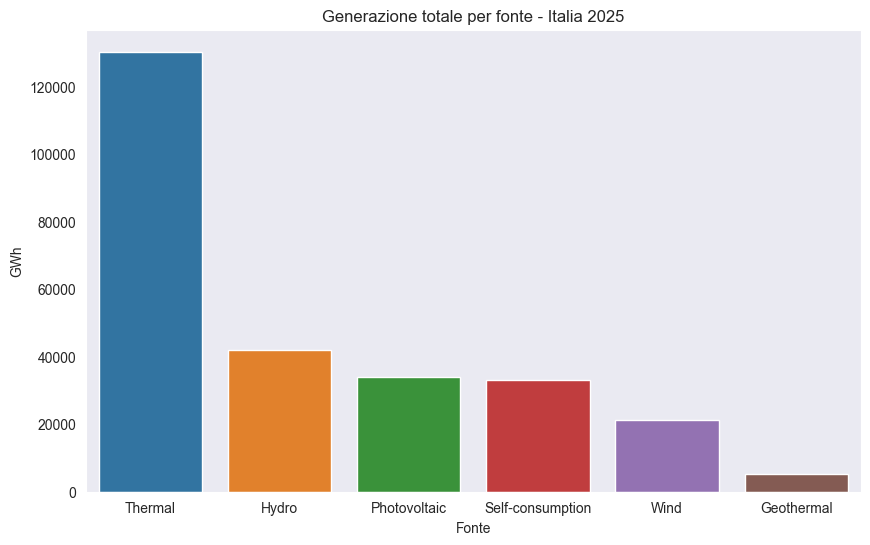

In [21]:
plt.figure(figsize=(10,6))
plt.title('Generazione totale per fonte - Italia 2025')
sns.barplot(data= gen_per_fonte,x='Primary Source', y='Actual Generation', hue= 'Primary Source')
plt.xlabel('Fonte')
plt.ylabel('GWh');


### Profilo medio giornaliero di ogni fonte:

In [22]:
dati_gw = dati_consumo.copy()
dati_gw['Actual Generation'] = dati_gw['Actual Generation'] / 0.25
colonna_ore = dati_gw['Date'].dt.hour
gen_oraria = dati_gw.groupby([colonna_ore, 'Primary Source'])['Actual Generation'].mean().reset_index()
gen_oraria.rename(columns={'Date':'Hours'}, inplace=True)
print(gen_oraria)

     Hours    Primary Source  Actual Generation
0        0        Geothermal           0.600740
1        0             Hydro           4.167808
2        0      Photovoltaic           0.000000
3        0  Self-consumption           2.207014
4        0           Thermal          13.140274
..     ...               ...                ...
139     23             Hydro           4.452000
140     23      Photovoltaic           0.000000
141     23  Self-consumption           2.576321
142     23           Thermal          15.226384
143     23              Wind           2.329699

[144 rows x 3 columns]


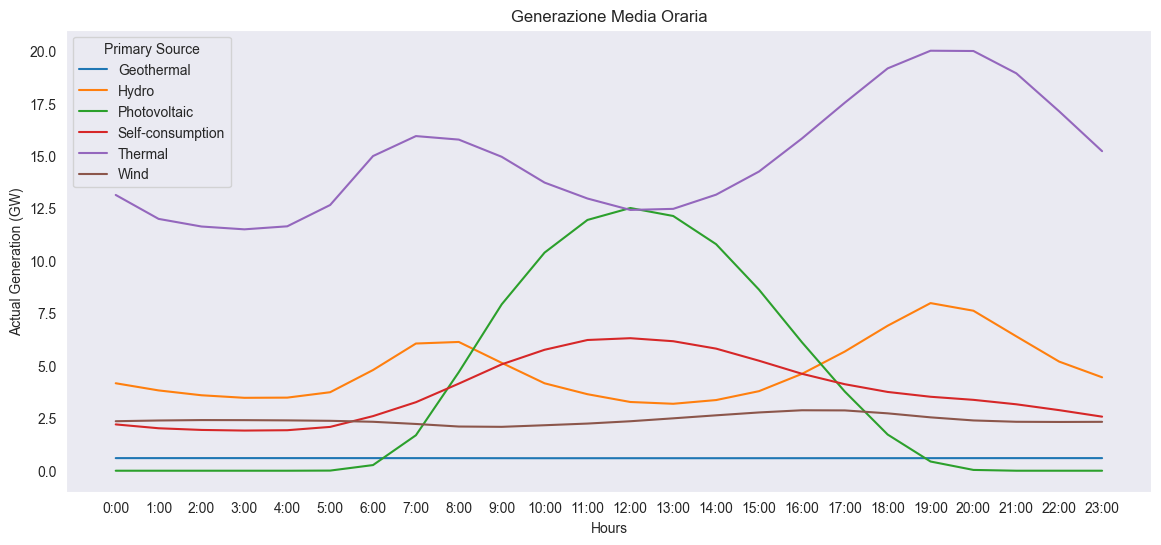

In [23]:
plt.figure(figsize=(14,6))
plt.title('Generazione Media Oraria')
sns.set_style('dark')
sns.lineplot(data= gen_oraria, x='Hours', y='Actual Generation', hue='Primary Source')
plt.ylabel('Actual Generation (GW)')
plt.xticks(range(24), [f'{num}:00' for num in range(24)]);

#### Osservazioni
Come era lecito aspettarsi abbiamo un picco di produzione di energia fotovoltaica nelle ore centrali ed un conseguente adeguamento del baseload fornito da idroelettrico e fonti termiche. Abbiamo poi un picco serale dell'idroelettrico dovuto agli impianti di pompaggio. Da notare infine la produzione costante dell'eolico nelle 24, non essendo legata al ciclo solare.